In [180]:
$Version
SetOptions[EvaluationNotebook[], 8]

14.3.0 for Microsoft Windows (64-bit) (July 31, 2025)

-Graphics-
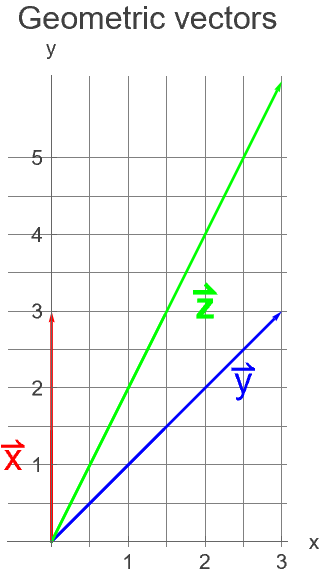

In [ ]:
(* Define two 2D vectors *)
x = {0, 3};  (* Example vector x *)
y = {3, 3};  (* Example vector y *)

(* Compute the sum z = x + y *)
z = x + y;

(* Plot the vectors x, y, and z as arrows from the origin *)
Graphics[{
  Red, Arrow[{{0, 0}, x}], Text[Style[OverVector["x"], Red, 14], {-0.5, 1.1}],  (* Vector x in red with overarrow label *)
  Blue, Arrow[{{0, 0}, y}], Text[Style[OverVector["y"], Blue, 14], {2.5, 2.1}], (* Vector y in blue with overarrow label *)
  Green, Arrow[{{0, 0}, z}], Text[Style[OverVector["z"], Green, Bold, 14], {2, 3.1}]  (* Vector z in green with bold overarrow label *)
},
  Axes -> True, 
  AxesLabel -> {Style["x", 8], Style["y", 8]},
  GridLines -> {
   (* x-grid: Solid black at 1-5, dashed gray at .5s *)
   Join[
    Table[{i, {Black, Thick}}, {i, 1, 5}],  (* Solid integers *)
    Table[{i + 0.5, {Gray, Dashed, Opacity[0.5]}}, {i, 0, 4}]  (* Dashed halves *)
   ],
   
   (* y-grid: Same *)
   Join[
    Table[{i, {Black, Thick}}, {i, 1, 5}],
    Table[{i + 0.5, {Gray, Dashed, Opacity[0.5]}}, {i, 0, 4}]
   ]
  },
  (* Scaled tick labels: Custom for y (12 pt), automatic styled for x (10 pt) *)
  Ticks -> {
    (* x-axis: Ticks at 1,2,3,4,5 with small labels *)
    Table[{i, Style[ToString[i], FontSize -> 8]}, {i, 1, 5}],
    
    (* y-axis: Same integer ticks, small labels *)
    Table[{i, Style[ToString[i], FontSize -> 8]}, {i, 1, 5}]
  },
  PlotLabel -> Style["Geometric vectors", FontSize -> 12],
  AspectRatio -> Automatic,
  ImageSize -> Small  (* Reduced size *)
]

Legended[-Graphics-, Placed[LineLegend[{Directive[Opacity[1.], RGBColor[0.24, 0.6, 0.8], 
 
>       AbsoluteThickness[2]], Directive[Opacity[1.], RGBColor[0.95, 0.627, 0.1425], 
 
>       AbsoluteThickness[2]], Directive[Opacity[1.], RGBColor[0.455, 0.7, 0.21], 
 
>       AbsoluteThickness[2]], Directive[Opacity[1.], 
 
>       RGBColor[0.922526, 0.385626, 0.209179], AbsoluteThickness[2]]}, 
 
>     {Linear: f1(x) = x + 1, Convex: f2(x) = x^2 - 2, Concave: f3(x) = -x^2 + 3, 
 
>      Inverse sigmoid-like: f4(x) = 1/(1 + e^x) - 0.5}, LegendMarkers -> None, 
 
>     LabelStyle -> {}, LegendLayout -> Column], After, Identity]]
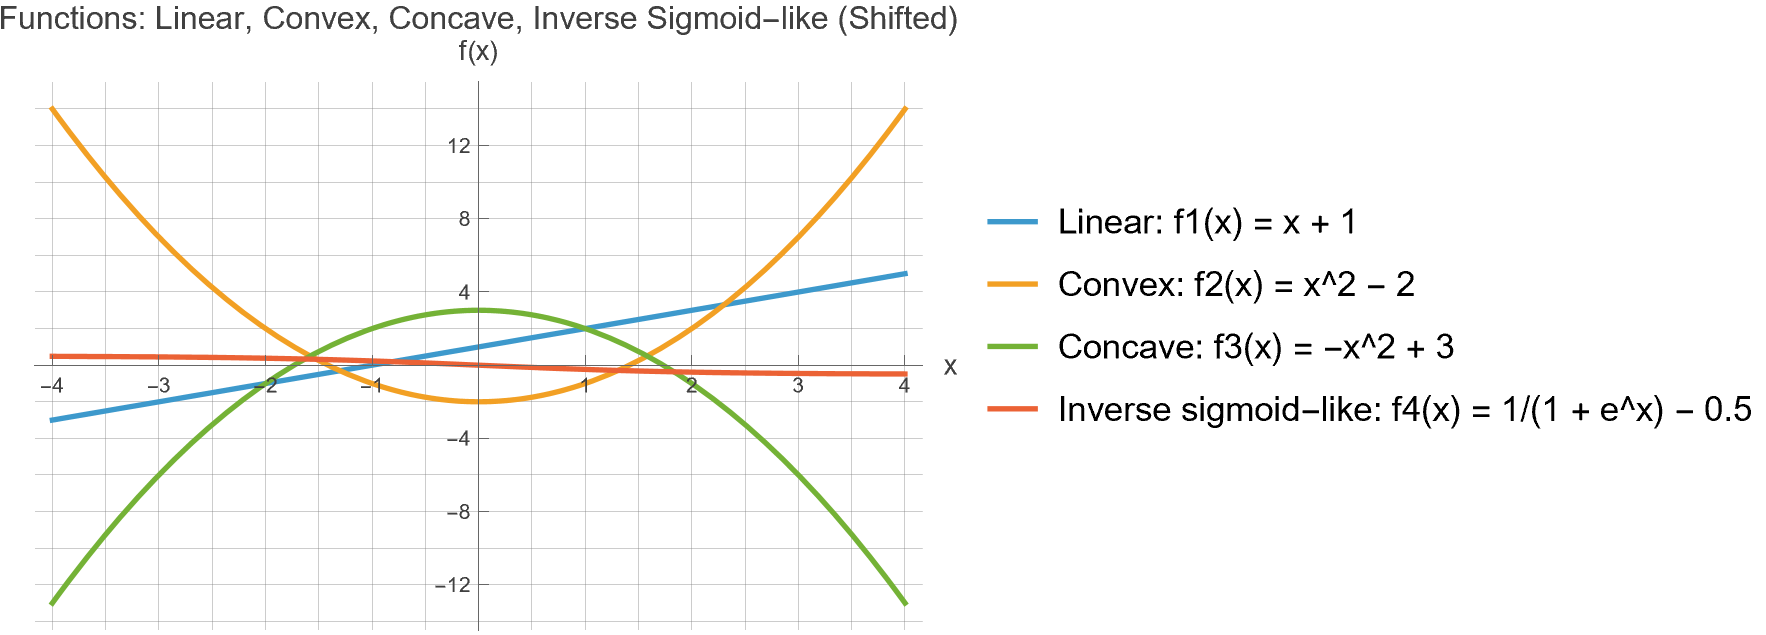

In [328]:
(* Define four univariate functions of different types in x, with vertical shifts to separate them *)
f1[x_] := x + 1;  (* Linear, shifted up by 1 *)
f2[x_] := x^2 - 2;  (* Convex quadratic, shifted down by 2 *)
f3[x_] := -x^2 + 3;  (* Concave quadratic, shifted up by 3 *)
f4[x_] := 1 / (1 + Exp[x]) - 0.5;  (* Inverse sigmoid-like, shifted down by 0.5 to avoid crowding near 0 *)

(* Plot all four functions in the same 2D plot over -4 <= x <= 4, with fixed ticks *)
Plot[{f1[x], f2[x], f3[x], f4[x]}, {x, -4, 4},
  PlotLegends -> {"Linear: f1(x) = x + 1", "Convex: f2(x) = x^2 - 2", "Concave: f3(x) = -x^2 + 3", "Inverse sigmoid-like: f4(x) = 1/(1 + e^x) - 0.5"},
  
  (* Scaled plot label *)
  PlotLabel -> Style["Functions: Linear, Convex, Concave, Inverse Sigmoid-like (Shifted)", FontSize -> 12],
  
  (* Scaled axes labels *)
  AxesLabel -> {Style["x", FontSize -> 10], Style["f(x)", FontSize -> 10]},
  
  (* Custom ticks: Simplified integers -4 to 4 on x; -16 to 16 step 4 on y, all small font (8 pt) *)
  Ticks -> {
    (* x-ticks: Integers -4 to 4 *)
    Table[{i, Style[ToString[i], FontSize -> 8]}, {i, -4, 4}],
    
    (* y-ticks: Fixed integers -16 to 16 step 4, no Module/rounding issues *)
    Table[{i, Style[ToString[i], FontSize -> 8]}, {i, -16, 16, 4}]
  },
  
  (* Mixed grid: Solid black at integers, dashed gray at halves; simplified for y-range *)
  GridLines -> {
    (* x-grid: Solid at -4 to 4 integers, dashed at halves *)
    Join[
     Table[{i, {Black, Thick}}, {i, -4, 4}],  (* Solid integers *)
     Table[{i + 0.5, {Gray, Dashed, Opacity[0.5]}}, {i, -4, 3}]  (* Dashed halves *)
    ],
    
    (* y-grid: Solid at -16 to 16 step 4, dashed at +2 offsets for visibility *)
    Join[
     Table[{i, {Black, Thick}}, {i, -16, 16, 4}],  (* Solid major integers *)
     Table[{i + 2, {Gray, Dashed, Opacity[0.5]}}, {i, -16, 12, 4}]  (* Dashed offsets *)
    ]
  },
  
  Frame -> False,  (* No frame *)
  Axes -> True,
  PlotRange -> All,
  ImageSize -> Medium
]

Manipulate[-Graphics3D-, {theta, 0, 2 Pi}, Animator -> False]
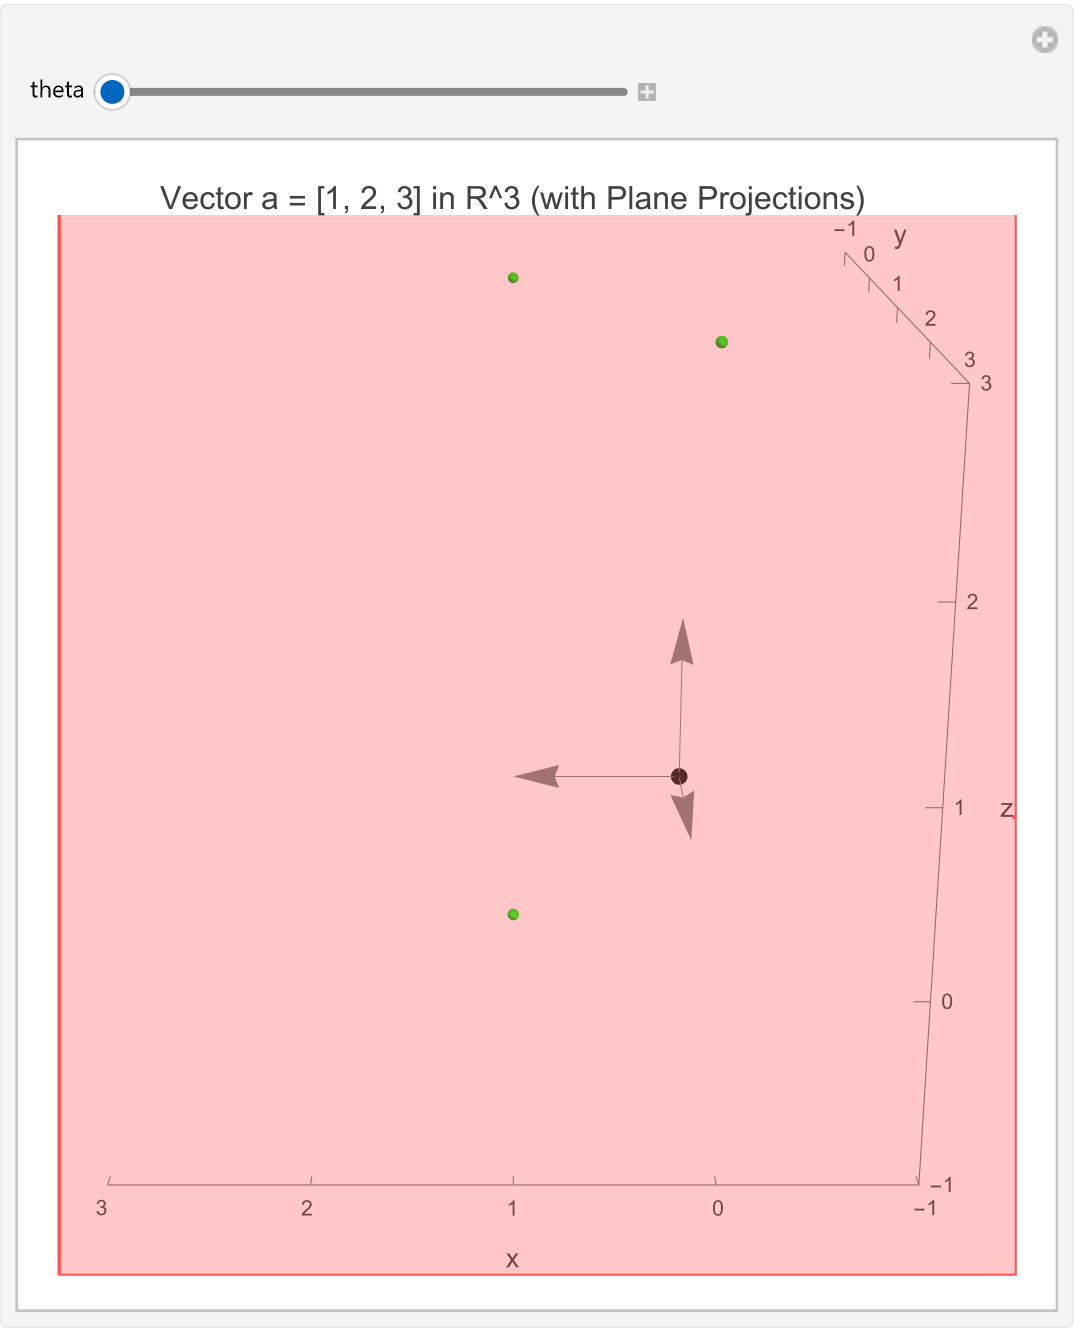

In [386]:
(* Define the vector a in R^3 *)
a = {1, 2, 3};

(* Interactive 3D plot with slider for azimuthal rotation of the coordinate system *)
Manipulate[
 Graphics3D[{
   (* Basis vectors for reference (thin gray arrows) *)
   Gray, Thin, 
   Arrow[{{0, 0, 0}, {1, 0, 0}}], 
   Arrow[{{0, 0, 0}, {0, 1, 0}}], 
   Arrow[{{0, 0, 0}, {0, 0, 1}}],
   
   (* Main vector a *)
   Red, Thick, Arrow[{{0, 0, 0}, a}],
   
   (* Reference points: Sphere at origin and tip *)
   Black, Opacity[0.7], Sphere[{0, 0, 0}, 0.05],  (* Origin marker *)
   Blue, Opacity[0.7], Sphere[a, 0.05],  (* Tip marker *)
   
   (* Projection points on planes (small green spheres) *)
   Green, Opacity[0.7], 
   Sphere[{1, 2, 0}, 0.03],  (* xy-plane projection (z=0) *)
   Sphere[{1, 0, 3}, 0.03],  (* xz-plane projection (y=0) *)
   Sphere[{0, 2, 3}, 0.03],  (* yz-plane projection (x=0) *)
   
   (* Lines from each Cartesian plane projection to the point (1,2,3); dashed purple *)
   Purple, Dashed, Opacity[0.6],
   Line[{{1, 2, 0}, a}],  (* From xy-plane *)
   Line[{{1, 0, 3}, a}],  (* From xz-plane *)
   Line[{{0, 2, 3}, a}],  (* From yz-plane *)
   
   (* Label at vector tip with coordinates *)
   Text[Style["a = (1, 2, 3)", FontSize -> 10, Bold], a + {0.2, 0.1, 0.1}]
  }, 
   Axes -> True, 
   Frame -> False, 
   Boxed -> False,  (* No bounding box *)
   
   (* Scaled plot label *)
   PlotLabel -> Style["Vector a = [1, 2, 3] in R^3 (with Plane Projections)", FontSize -> 12],
   
   (* Scaled axes labels *)
   AxesLabel -> {Style["x", FontSize -> 10], Style["y", FontSize -> 10], Style["z", FontSize -> 10]},
   
   (* Custom ticks: Simplified integers -1 to 3 on each axis, small font (8 pt) *)
   Ticks -> {
     Table[{i, Style[ToString[i], FontSize -> 8]}, {i, -1, 3}],
     Table[{i, Style[ToString[i], FontSize -> 8]}, {i, -1, 3}],
     Table[{i, Style[ToString[i], FontSize -> 8]}, {i, -1, 3}]
   },
   
   (* Simplified dashed grid planes for background reference *)
   GridLines -> {
     {-1, 0, 1, 2, 3}, 
     {-1, 0, 1, 2, 3}, 
     {-1, 0, 1, 2, 3}
   },
   GridLinesStyle -> Directive[Gray, Dashed, Opacity[0.3]],
   
   PlotRange -> {{-1, 3}, {-1, 3}, {-1, 3}},  (* Fixed range *)
   ImageSize -> Medium,
   
   (* Enhanced 3D view: Lighting and dynamic viewpoint for rotation *)
   Lighting -> "Neutral",
   ViewPoint -> {3 Sin[theta], 3 Cos[theta], 1}  (* Slider rotates azimuthally around y-axis; adjust r=3 for distance *)
  ],
 (* Slider for rotation angle theta (0 to 2 Pi radians, full circle); no auto-animation *)
 {theta, 0, 2 Pi},
 Animator -> False  (* Disables automatic animation/play button *)
]

-Graphics-
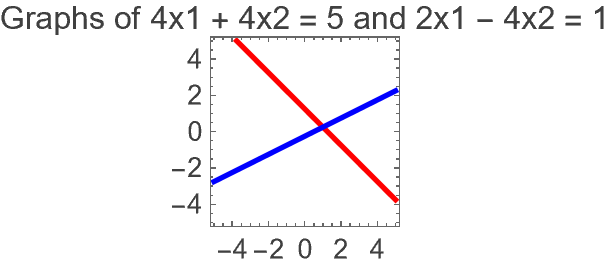

In [216]:
(* Plot the two linear equations as lines in the x1-x2 plane *)
ContourPlot[{4 x1 + 4 x2 == 5, 2 x1 - 4 x2 == 1}, {x1, -5, 5}, {x2, -5, 5},
  ContourStyle -> {Red, Blue},  (* Red for first equation, Blue for second *)
  ContourLabels -> True,  (* Label the contours *)
  AxesLabel -> {"x1", "x2"}, 
  PlotLabel -> "Graphs of 4x1 + 4x2 = 5 and 2x1 - 4x2 = 1",
  AspectRatio -> Automatic,
  ImageSize -> Tiny
]

1
{1, -}
    4
True
AugmentedMatrix[{{4, 4}, {2, -4}}, {5, 1}]
RowReduce[AugmentedMatrix[{{4, 4}, {2, -4}}, {5, 1}]]
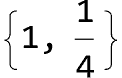
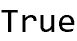
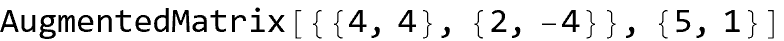
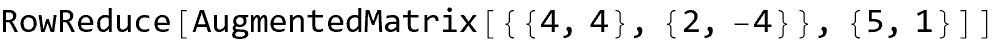

In [7]:
(* Define the coefficient matrix A and constant vector b *)
A = {{4, 4}, {2, -4}};  (* Coefficient matrix *)
b = {5, 1};  (* Constant vector *)

(* Solve the system A x = b using LinearSolve *)
x = LinearSolve[A, b];  (* Returns {x1, x2} *)

(* Display the solution *)
x  (* Output: {3/2, 1/2} or {1.5, 0.5} *)

(* Optional: Verify by plugging back in *)
A . x == b  (* Should return True *)

(* Optional: Augmented matrix and row reduction visualization *)
MatrixForm[AugmentedMatrix[A, b]]  (* Shows the augmented matrix *)
RowReduce[AugmentedMatrix[A, b]]  (* Row-reduced echelon form *)